# Make Segments

## Clean dataset

In [ ]:
from fn.pipeline import *
preprocess_and_save_dataset(
    r"data\machine_translation_docs_info.json",
    r"data\translation_dataset.pkl"
)
preprocess_and_save_dataset(
    r"data\machine_learning_docs_info.json",
    r"data\learning_dataset.pkl"
)

Preprocessing dataset...
Saved processed dataset to data\translation_dataset.pkl
Preprocessing dataset...
Saved processed dataset to data\learning_dataset.pkl



=== TRANSLATION ===


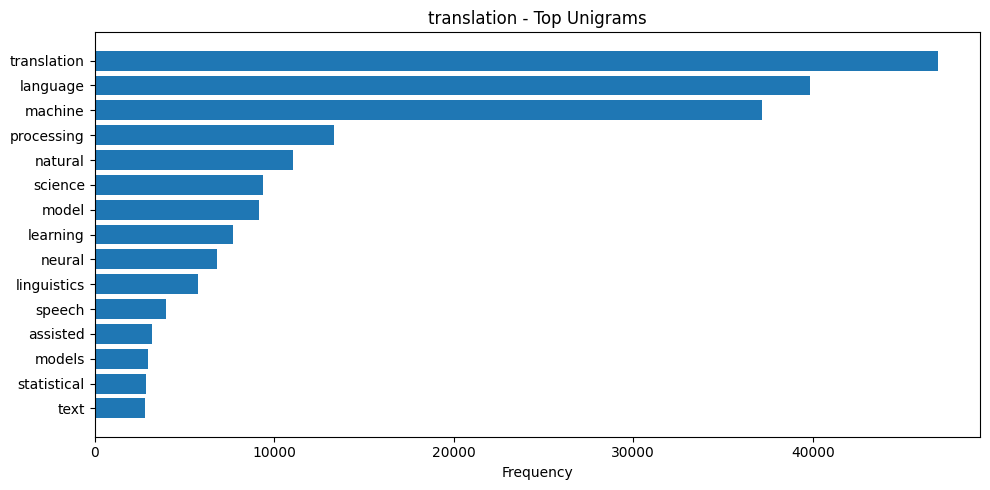

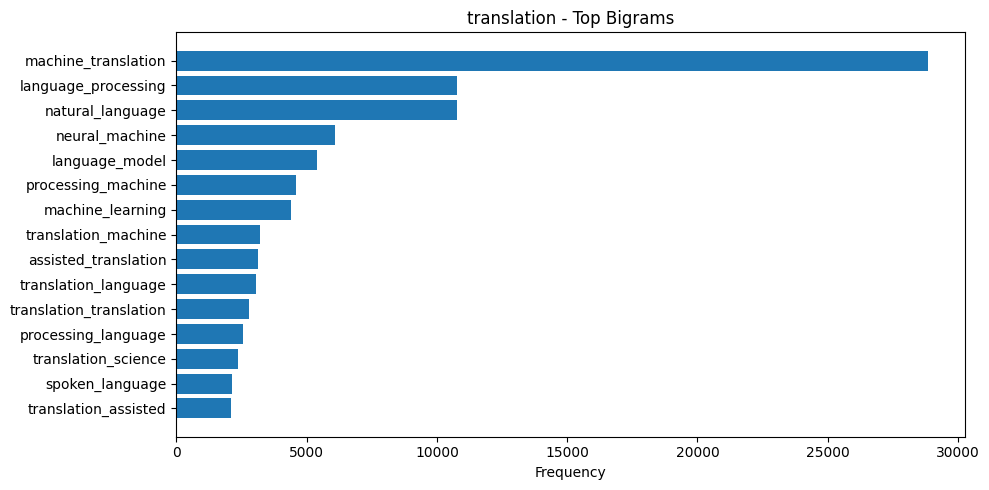

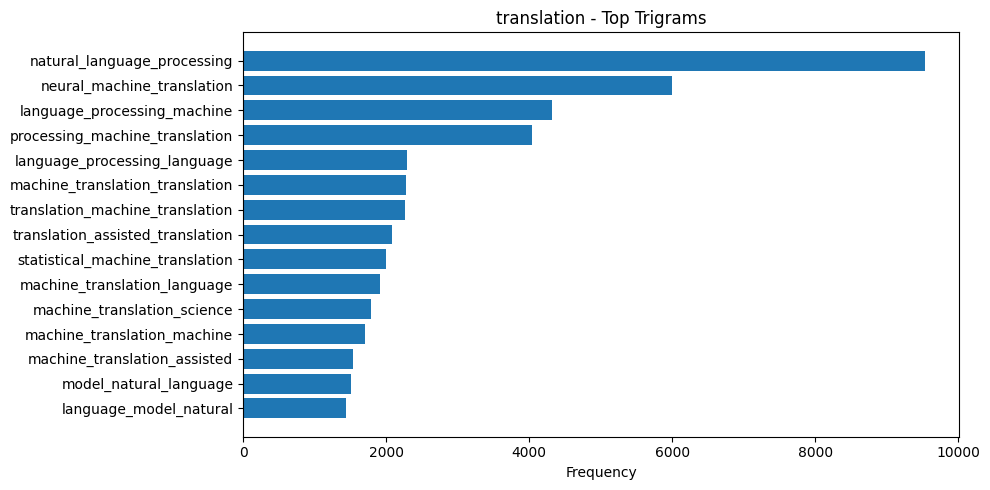

In [ ]:
import pickle
from collections import Counter
import matplotlib.pyplot as plt


def extract_ngrams(tokens_list):
    unigram = Counter()
    bigram = Counter()
    trigram = Counter()

    for tokens in tokens_list:
        unigram.update(tokens)

        bigram.update([
            "_".join(tokens[i:i+2])
            for i in range(len(tokens)-1)
        ])

        trigram.update([
            "_".join(tokens[i:i+3])
            for i in range(len(tokens)-2)
        ])

    return unigram, bigram, trigram


def plot_top(counter, title, top_n=15):
    most_common = counter.most_common(top_n)

    words = [w for w, _ in most_common]
    counts = [c for _, c in most_common]

    plt.figure(figsize=(10, 5))
    plt.barh(words[::-1], counts[::-1])
    plt.title(title)
    plt.xlabel("Frequency")
    plt.tight_layout()
    plt.show()


def visualize_dataset(dataset_path, name="dataset"):
    with open(dataset_path, "rb") as f:
        year_groups = pickle.load(f)

    # flatten tokens
    all_tokens = []
    for docs in year_groups.values():
        for doc in docs:
            all_tokens.append(doc["tokens"])

    unigram, bigram, trigram = extract_ngrams(all_tokens)

    print(f"\n=== {name.upper()} ===")

    plot_top(unigram, f"{name} - Top Unigrams")
    plot_top(bigram, f"{name} - Top Bigrams")
    plot_top(trigram, f"{name} - Top Trigrams")

visualize_dataset(r"data\translation_dataset.pkl", name="translation")



=== LEARNING ===


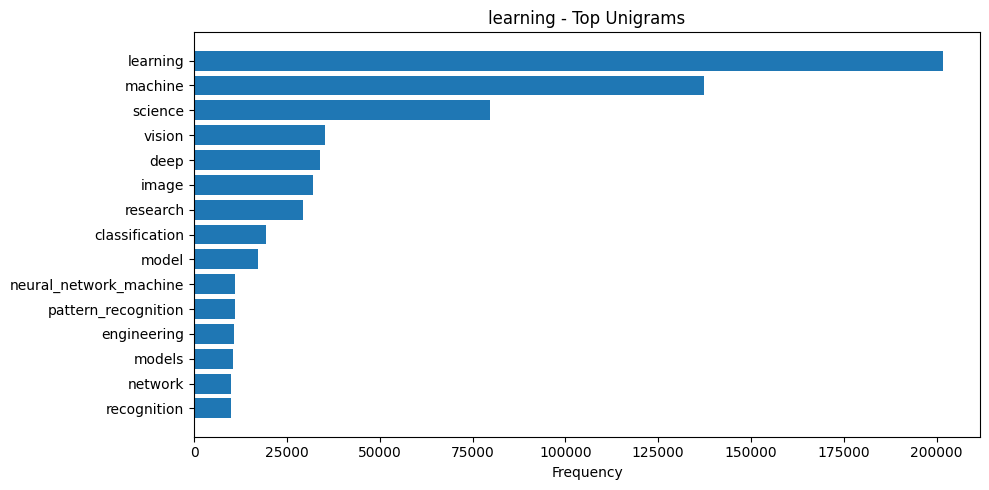

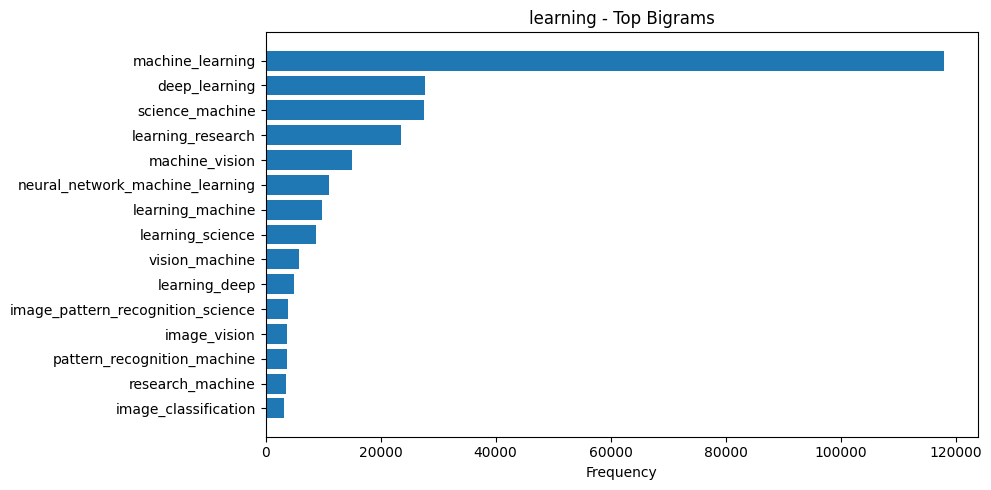

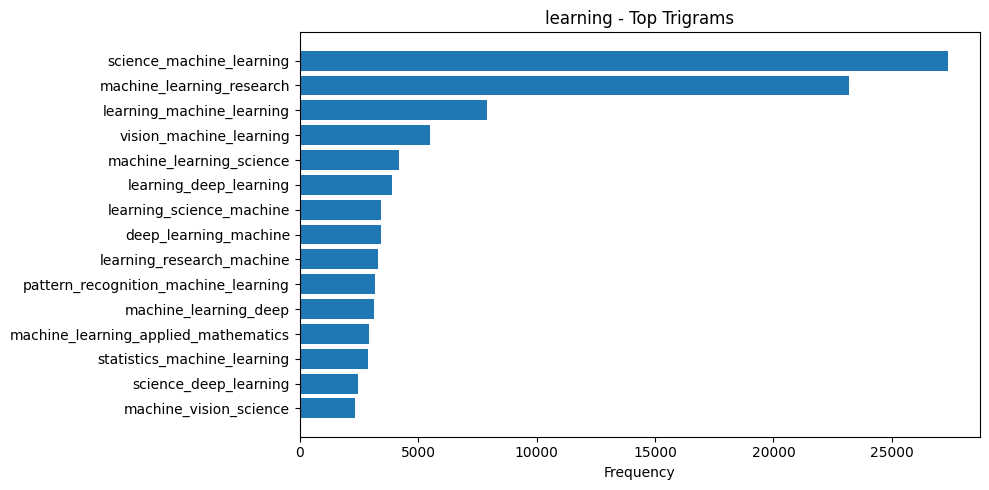

In [ ]:
visualize_dataset(r"data\learning_dataset.pkl", name="learning")

## Train DMR Models

In [ ]:
from fn.pipeline import train_dmr_model
train_dmr_model(
    r"data\translation_dataset.pkl",
    r"models\trans_dmr.bin",
    k_topics=25,
    iterations=1900,
    log_filename="mt_log.txt"    
)


Training DMR model...
Iter 10: LL per word = -8.523878
Iter 20: LL per word = -8.097249
Iter 30: LL per word = -7.918276
Iter 40: LL per word = -7.816392
Iter 50: LL per word = -7.746623
Iter 60: LL per word = -7.701224
Iter 70: LL per word = -7.665309
Iter 80: LL per word = -7.640340
Iter 90: LL per word = -7.618129
Iter 100: LL per word = -7.597796
Iter 110: LL per word = -7.586660
Iter 120: LL per word = -7.572581
Iter 130: LL per word = -7.562813
Iter 140: LL per word = -7.555369
Iter 150: LL per word = -7.548293
Iter 160: LL per word = -7.543067
Iter 170: LL per word = -7.537792
Iter 180: LL per word = -7.532643
Iter 190: LL per word = -7.527151
Iter 200: LL per word = -7.524735
Iter 210: LL per word = -7.516214
Iter 220: LL per word = -7.513841
Iter 230: LL per word = -7.509121
Iter 240: LL per word = -7.512321
Iter 250: LL per word = -7.507046
Iter 260: LL per word = -7.502211
Iter 270: LL per word = -7.499910
Iter 280: LL per word = -7.499903
Iter 290: LL per word = -7.495520
I

In [ ]:
train_dmr_model(
    r"data\learning_dataset.pkl",
    r"models\learning_dmr.bin",
    k_topics=30,
    iterations=5000,
    log_filename = "ml_log.txt"
)

Training DMR model...


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\tomotopy\models.py:637: RuntimeWarning: The training result may differ even with fixed seed if `workers` != 1.
  return self._train(iterations, workers, parallel, freeze_topics, callback_interval, callback)


Iter 10: LL per word = -9.330671
Iter 20: LL per word = -8.686153
Iter 30: LL per word = -8.428049
Iter 40: LL per word = -8.296531
Iter 50: LL per word = -8.215322
Iter 60: LL per word = -8.163901
Iter 70: LL per word = -8.122797
Iter 80: LL per word = -8.093375
Iter 90: LL per word = -8.071219
Iter 100: LL per word = -8.054678
Iter 110: LL per word = -8.041164
Iter 120: LL per word = -8.029784
Iter 130: LL per word = -8.018877
Iter 140: LL per word = -8.008554
Iter 150: LL per word = -8.000110
Iter 160: LL per word = -7.993921
Iter 170: LL per word = -7.990044
Iter 180: LL per word = -7.986051
Iter 190: LL per word = -7.981222
Iter 200: LL per word = -7.976884
Iter 210: LL per word = -7.973770
Iter 220: LL per word = -7.972147
Iter 230: LL per word = -7.968601
Iter 240: LL per word = -7.964694
Iter 250: LL per word = -7.962015
Iter 260: LL per word = -7.960102
Iter 270: LL per word = -7.958526
Iter 280: LL per word = -7.957048
Iter 290: LL per word = -7.956815
Iter 300: LL per word =

## Elbow Method Visualization

Running lambda = 0.00
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.05
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.10
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.15
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.20
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.25
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.30
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.35
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.40
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.45
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.50
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.55
Extracting topic distributions...
Running segmentation DP...
Runn

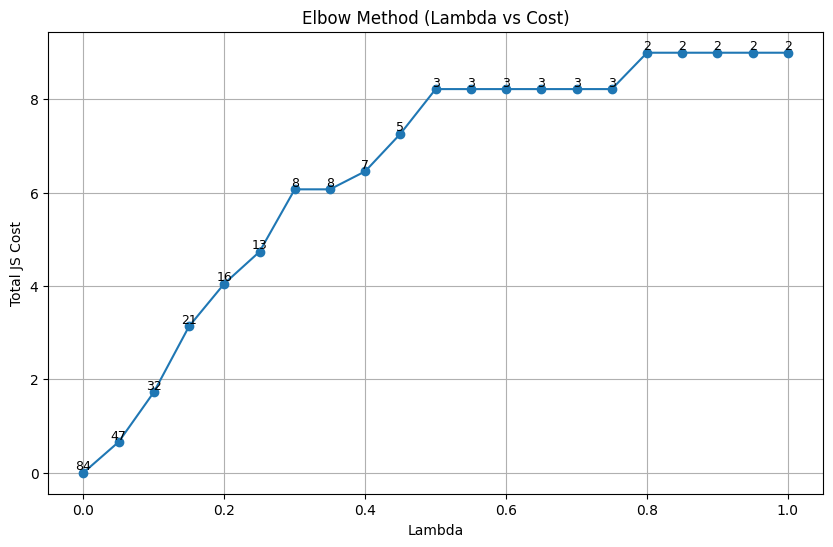

In [ ]:
from fn.utils import sweep_lambda, plot_elbow
dataset_path = r"data\translation_dataset.pkl"
model_path = r"models\trans_dmr.bin"

lambdas, costs, segments = sweep_lambda(dataset_path, model_path)

plot_elbow(lambdas, costs, segments)

Running lambda = 0.00
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.05
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.10
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.15
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.20
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.25
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.30
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.35
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.40
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.45
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.50
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.55
Extracting topic distributions...
Running segmentation DP...
Runn

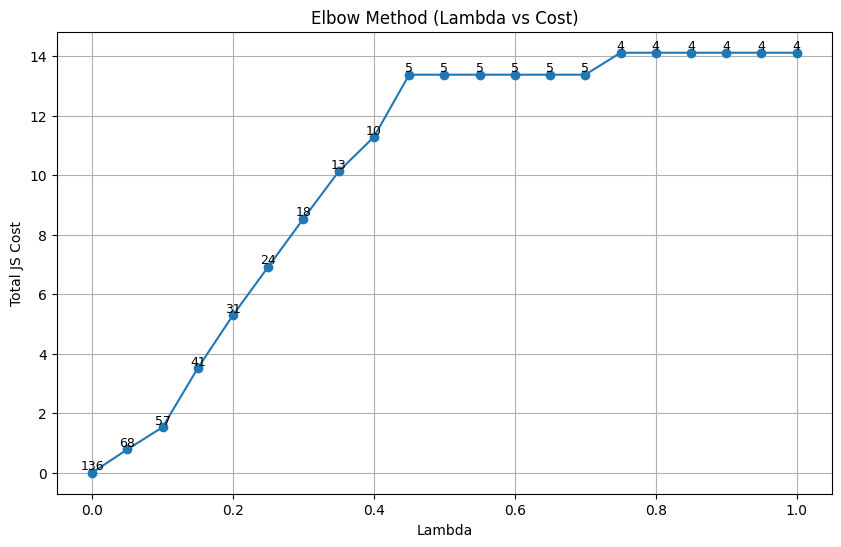

In [3]:
from fn.utils import sweep_lambda, plot_elbow
dataset_path = r"data\learning_dataset.pkl"
model_path = r"models\learning_dmr.bin"
lambdas, costs, segments = sweep_lambda(dataset_path, model_path)

plot_elbow(lambdas, costs, segments)


In [ ]:
import tomotopy as tp


def print_dmr_topics(model, top_n=10):
    for topic_id in range(model.k):
        words = model.get_topic_words(topic_id, top_n=top_n)

        topic_str = ", ".join([
            f"{w}:{p:.3f}"   
            for w, p in words
        ])

        print(f"Topic {topic_id:02d}: {topic_str}")


model = tp.DMRModel.load("models/trans_dmr.bin")

print_dmr_topics(model, top_n=10)

Topic 00: language:0.068, machine:0.044, science:0.033, corpus:0.033, processing:0.029, natural:0.029, text_mining:0.023, corpus_linguistics:0.022, translation:0.016, learning_research:0.016
Topic 01: translation:0.066, machine:0.063, science:0.029, efficient:0.019, learning:0.019, decoding:0.015, models:0.014, simultaneous:0.014, adaptive:0.012, search:0.011
Topic 02: translation:0.054, machine:0.026, engineering:0.022, science:0.020, software:0.016, code:0.013, program:0.013, open_source:0.008, implementation:0.008, programming:0.008
Topic 03: machine:0.080, language:0.079, learning:0.070, model:0.044, deep_learning:0.042, natural:0.032, processing:0.029, science:0.025, learning_research:0.019, neural_network:0.016
Topic 04: translation:0.028, biology:0.015, protein:0.013, machine:0.013, scp_scp:0.012, molecular_biology:0.010, sequences:0.007, prediction:0.007, rna:0.007, bioinformatics:0.006
Topic 05: language:0.106, recognition:0.050, machine:0.041, processing:0.040, sign:0.034, te

## Choose lambda and postprocess segments

### Machine Translation

In [4]:
import os
import pandas as pd

from fn.pipeline import build_timeline_from_model
from fn.utils import segments_to_dataframe 


def run_timeline_and_save():
    dataset_path = r"data\translation_dataset.pkl"
    model_path = r"models\trans_dmr.bin"

    print("Running timeline model...")

    result = build_timeline_from_model(
        dataset_path=dataset_path,
        model_path=model_path,
        lambda_penalty=0.15,
        k_topics=25
    )

    print("Converting to dataframe...")

    df = segments_to_dataframe(result)

    output_path = r"data\timeline_segments.csv"

    print("Saving to:", output_path)
    df.to_csv(output_path, index=False, encoding="utf-8")

    print("Done. Rows:", len(df))

    return df

mt_df=run_timeline_and_save()
mt_df

Running timeline model...
Extracting topic distributions...
Running segmentation DP...
Converting to dataframe...
Saving to: data\timeline_segments.csv
Done. Rows: 21


,start_year,end_year,period,num_docs,topic,topic_vector
0,1819,1819,1,1,8,"[0.0010713941883295774, 0.004484651144593954, ..."
1,1852,1852,1,1,17,"[0.009317152202129364, 0.0008769867126829922, ..."
2,1899,1899,1,1,11,"[0.0005615422269329429, 0.020719559863209724, ..."
3,1933,1933,1,2,15,"[0.021985506638884544, 0.0005117002874612808, ..."
4,1941,1941,1,2,17,"[0.0013071701396256685, 0.0018226985121145844,..."
5,1942,1942,1,1,23,"[0.04276241734623909, 0.002031297655776143, 0...."
6,1943,1947,2,3,15,"[0.0400498453527689, 0.0035667577758431435, 0...."
7,1949,1949,1,1,4,"[0.1102631688117981, 0.0012792054330930114, 0...."
8,1950,1950,1,1,11,"[0.006134199909865856, 0.006825252901762724, 0..."
9,1951,1951,1,3,15,"[0.006186867132782936, 0.0007750653312541544, ..."


In [15]:
import numpy as np
import pandas as pd


def merge_segments(df, min_docs=10):
    df = df[df["num_docs"] >= min_docs].copy()
    df = df.sort_values("start_year").reset_index(drop=True)

    merged_rows = []
    current = None

    for _, row in df.iterrows():
        vec = np.array(row["topic_vector"], dtype=np.float32)

        start_year = int(row["start_year"])
        end_year = int(row["end_year"])

        if current is None:
            current = {
                "start_year": start_year,
                "end_year": end_year,
                "num_docs": row["num_docs"],
                "topic": row["topic"],
                "vector_sum": vec * row["num_docs"]
            }
            continue

        if row["topic"] == current["topic"]:
            current["end_year"] = end_year
            current["num_docs"] += row["num_docs"]
            current["vector_sum"] += vec * row["num_docs"]

        else:
            bary = current["vector_sum"] / current["num_docs"]

            merged_rows.append({
                "start_year": current["start_year"],
                "end_year": current["end_year"],
                "period": current["end_year"] - current["start_year"] + 1,
                "num_docs": current["num_docs"],
                "topic": current["topic"],
                "topic_vector": bary.tolist()
            })

            current = {
                "start_year": start_year,
                "end_year": end_year,
                "num_docs": row["num_docs"],
                "topic": row["topic"],
                "vector_sum": vec * row["num_docs"]
            }

    # finalize
    if current is not None:
        bary = current["vector_sum"] / current["num_docs"]

        merged_rows.append({
            "start_year": current["start_year"],
            "end_year": current["end_year"],
            "period": current["end_year"] - current["start_year"] + 1,
            "num_docs": current["num_docs"],
            "topic": current["topic"],
            "topic_vector": bary.tolist()
        })

    return pd.DataFrame(merged_rows)

merge_segments(mt_df).to_csv(r"output\mt_df.csv", index=False)
merge_segments(mt_df)

,start_year,end_year,period,num_docs,topic,topic_vector
0,1957,1959,3,10,15,"[0.006225883960723877, 0.060094643384218216, 0..."
1,1960,1964,5,32,21,"[0.023802731186151505, 0.011801773682236671, 0..."
2,1965,1968,4,27,23,"[0.002659847727045417, 0.036055997014045715, 0..."
3,1969,1983,15,182,15,"[0.029065147042274475, 0.013248486444354057, 0..."
4,1984,2000,17,735,21,"[0.04460464417934418, 0.013098245486617088, 0...."
5,2001,2024,24,7236,12,"[0.0316847488284111, 0.019675087183713913, 0.0..."


In [ ]:
import os
import pandas as pd

from fn.pipeline import build_timeline_from_model
from fn.utils import segments_to_dataframe  # hàm bạn vừa sửa


def run_timeline_and_save():
    dataset_path = r"data\learning_dataset.pkl"
    model_path = r"models\learning_dmr.bin"

    print("Running timeline model...")

    result = build_timeline_from_model(
        dataset_path=dataset_path,
        model_path=model_path,
        lambda_penalty=0.1,
        k_topics=25
    )

    print("Converting to dataframe...")

    df = segments_to_dataframe(result)

    output_path = r"data\timeline_segments.csv"

    print("Saving to:", output_path)
    df.to_csv(output_path, index=False, encoding="utf-8")

    print("Done. Rows:", len(df))

    return df

ml_df=run_timeline_and_save()
ml_df

Running timeline model...
Extracting topic distributions...
Running segmentation DP...
Converting to dataframe...
Saving to: data\timeline_segments.csv
Done. Rows: 57


,start_year,end_year,period,num_docs,topic,topic_vector
0,1744,1744,1,1,4,"[0.001829843269661069, 0.002875695703551173, 0..."
1,1801,1801,1,1,20,"[0.23706236481666565, 0.00154121033847332, 0.0..."
2,1819,1819,1,1,25,"[0.008668595924973488, 0.00570402666926384, 0...."
3,1842,1842,1,1,2,"[0.0024738970678299665, 0.00045324134407565, 0..."
4,1852,1852,1,1,18,"[0.018056627362966537, 0.00038691976806148887,..."
5,1856,1856,1,1,0,"[0.5354709029197693, 0.0019438028102740645, 0...."
6,1859,1859,1,1,22,"[0.15790808200836182, 0.018174398690462112, 0...."
7,1865,1865,1,2,28,"[0.002917958190664649, 0.018797675147652626, 0..."
8,1886,1886,1,1,16,"[0.0024785231798887253, 0.003686529118567705, ..."
9,1888,1888,1,1,24,"[0.02196267992258072, 0.006826191209256649, 0...."


In [14]:
merge_segments(ml_df).to_csv(r"output\ml_df.csv", index=False)
merge_segments(ml_df)

,start_year,end_year,period,num_docs,topic,topic_vector
0,1931,1932,2,15,5,"[0.00555633706972003, 0.0066978647373616695, 0..."
1,1939,1939,1,14,2,"[0.004025845788419247, 0.0021442321594804525, ..."
2,1940,1943,4,41,24,"[0.015508783981204033, 0.006809914950281382, 0..."
3,1945,1951,7,154,2,"[0.03411106765270233, 0.004258482716977596, 0...."
4,1952,1966,15,1083,5,"[0.03542236238718033, 0.007362012751400471, 0...."
5,1967,2014,48,32006,22,"[0.05474179610610008, 0.011199270375072956, 0...."
6,2015,2024,10,9350,12,"[0.029120417311787605, 0.03621530905365944, 0...."


# Make Details

In [ ]:
from fn.make_details import make_details
make_details(
    r"output\mt_df.csv",
    r"data\machine_translation_docs_info.json",
    r"models\trans_dmr.bin",
    r"output\mt.json"
)
import json

with open("output/mt.json", "r", encoding="utf-8") as f:
    data = json.load(f)

print(json.dumps(data, indent=2, ensure_ascii=False))

TypeError: make_details() missing 1 required positional argument: 'output_path'